In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy.stats import stats as st
import statsmodels.api as sm

import sklearn
from sklearn.preprocessing import LabelEncoder,MinMaxScaler
from sklearn.model_selection import train_test_split,GridSearchCV, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor 
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor 
from sklearn.metrics import r2_score,mean_squared_error 

plt.style.use("ggplot")
import warnings
warnings.filterwarnings("ignore")

# ****Reading Data****

In [4]:
df = pd.read_csv('/kaggle/input/datasets/gauravmalik26/food-delivery-dataset/train.csv')
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [6]:
df.shape

(45593, 20)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Restaurant_latitude,45593.0,17.017729,8.185109,-30.905562,12.933284,18.546947,22.728163,30.914057
Restaurant_longitude,45593.0,70.231332,22.883647,-88.366217,73.170000,75.898497,78.044095,88.433452
Delivery_location_latitude,45593.0,17.465186,7.335122,0.010000,12.988453,18.633934,22.785049,31.054057
Delivery_location_longitude,45593.0,70.845702,21.118812,0.010000,73.280000,76.002574,78.107044,88.563452
Vehicle_condition,45593.0,1.023359,0.839065,0.000000,0.000000,1.000000,2.000000,3.000000


In [9]:
df.describe(include="object")

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
count,45593,45593,45593,45593,45593,45593,45593,45593,45593,45593,45593,45593,45593,45593,45593
unique,45593,1320,23,29,44,177,193,7,5,4,4,5,3,4,45
top,0x5fb2,PUNERES01DEL01,35,4.8,15-03-2022,NaN,21:30:00,conditions Fog,Low,Snack,motorcycle,1,No,Metropolitian,(min) 26
freq,1,67,2262,7148,1192,1731,496,7654,15477,11533,26435,28159,44469,34093,2123


# ****Data Preprocessing and Visualization****

In [10]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [11]:
# Rename the column names 

df.rename(columns = {"City":"City_area","Weatherconditions":"Weather_conditions","Time_taken(min)":"Time_taken"},inplace=True)

Extracting city from delivery person id col

Extracting time from time taken col and coverting to int

In [12]:
df["City"] = df["Delivery_person_ID"].str.split("RES").str[0]
df["Time_taken"] = df["Time_taken"].str.split(" ").str[-1].astype("int")

In [13]:
# drop unuseful columns 

df.drop(columns = ["ID","Delivery_person_ID"],axis=1,inplace=True)

In [14]:
# checking duplicates 

df[df.duplicated()]

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City_area,Time_taken,City


In [15]:
# checking null values 

df.isnull().sum()

Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weather_conditions             0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City_area                      0
Time_taken                     0
City                           0
dtype: int64

In [16]:
# we have seen already nan in describe method 

nan_length = df["Time_Orderd"].value_counts().index[0]
print(f"{nan_length} nan_length : {len(nan_length)}")

NaN  nan_length : 4


In [17]:
# checking string value of nan in every column may be there are chances that they have written in other form like 'nan'

df1 = df.select_dtypes(include = "object")

for col in df1.columns:
    nan_count = (df1[col].apply(lambda x:x.strip().lower().find("nan"))>=0).sum()
    print(f"{col} null count : {nan_count}")

Delivery_person_Age null count : 1854
Delivery_person_Ratings null count : 1908
Order_Date null count : 0
Time_Orderd null count : 1731
Time_Order_picked null count : 0
Weather_conditions null count : 616
Road_traffic_density null count : 601
Type_of_order null count : 0
Type_of_vehicle null count : 0
multiple_deliveries null count : 993
Festival null count : 228
City_area null count : 1200
City null count : 0


In [18]:
# replacing string nan with float nan 

for col in df1.columns:
    df1[col] = df1[col].apply(lambda x:x.strip().lower())
    df1[col].replace("nan",np.nan,regex = True,inplace=True)

In [19]:
# again checking nulls 

df1.isnull().sum().sort_values(ascending=False)

Delivery_person_Ratings    1908
Delivery_person_Age        1854
Time_Orderd                1731
City_area                  1200
multiple_deliveries         993
Weather_conditions          616
Road_traffic_density        601
Festival                    228
Order_Date                    0
Time_Order_picked             0
Type_of_order                 0
Type_of_vehicle               0
City                          0
dtype: int64

In [20]:
df2 = pd.concat([df1,df.select_dtypes(exclude="object")],axis=1)
df2.head()

,Delivery_person_Age,Delivery_person_Ratings,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City_area,City,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,Time_taken
0,37,4.9,19-03-2022,11:30:00,11:45:00,conditions sunny,high,snack,motorcycle,0,no,urban,indo,22.745049,75.892471,22.765049,75.912471,2,24
1,34,4.5,25-03-2022,19:45:00,19:50:00,conditions stormy,jam,snack,scooter,1,no,metropolitian,bang,12.913041,77.683237,13.043041,77.813237,2,33
2,23,4.4,19-03-2022,08:30:00,08:45:00,conditions sandstorms,low,drinks,motorcycle,1,no,urban,bang,12.914264,77.678400,12.924264,77.688400,0,26
3,38,4.7,05-04-2022,18:00:00,18:10:00,conditions sunny,medium,buffet,motorcycle,1,no,metropolitian,coimb,11.003669,76.976494,11.053669,77.026494,0,21
4,32,4.6,26-03-2022,13:30:00,13:45:00,conditions cloudy,high,snack,scooter,1,no,metropolitian,chen,12.972793,80.249982,13.012793,80.289982,1,30


In [22]:
# updating the datatype 

df2["Delivery_person_Age"] = df2["Delivery_person_Age"].astype("float")
df2["Delivery_person_Ratings"] = df2["Delivery_person_Ratings"].astype("float")
df2["Order_Date"] = pd.to_datetime(df2["Order_Date"])
df2["multiple_deliveries"] = df2["multiple_deliveries"].astype("float")

In [23]:
for col in df2.select_dtypes(include="object").columns[2:]:
    print(f"{col}\n{df2[col].value_counts()}")
    print()

Weather_conditions
Weather_conditions
conditions fog           7654
conditions stormy        7586
conditions cloudy        7536
conditions sandstorms    7495
conditions windy         7422
conditions sunny         7284
Name: count, dtype: int64

Road_traffic_density
Road_traffic_density
low       15477
jam       14143
medium    10947
high       4425
Name: count, dtype: int64

Type_of_order
Type_of_order
snack     11533
meal      11458
drinks    11322
buffet    11280
Name: count, dtype: int64

Type_of_vehicle
Type_of_vehicle
motorcycle          26435
scooter             15276
electric_scooter     3814
bicycle                68
Name: count, dtype: int64

Festival
Festival
no     44469
yes      896
Name: count, dtype: int64

City_area
City_area
metropolitian    34093
urban            10136
semi-urban         164
Name: count, dtype: int64

City
City
jap       3443
ranchi    3229
bang      3195
sur       3187
hyd       3181
mum       3173
mys       3171
coimb     3170
vad       3166
indo    

In [24]:
# extracting only the weather type from column

df2["Weather_conditions"] = df2["Weather_conditions"].str.split(" ").str[-1]

Target variable visualization

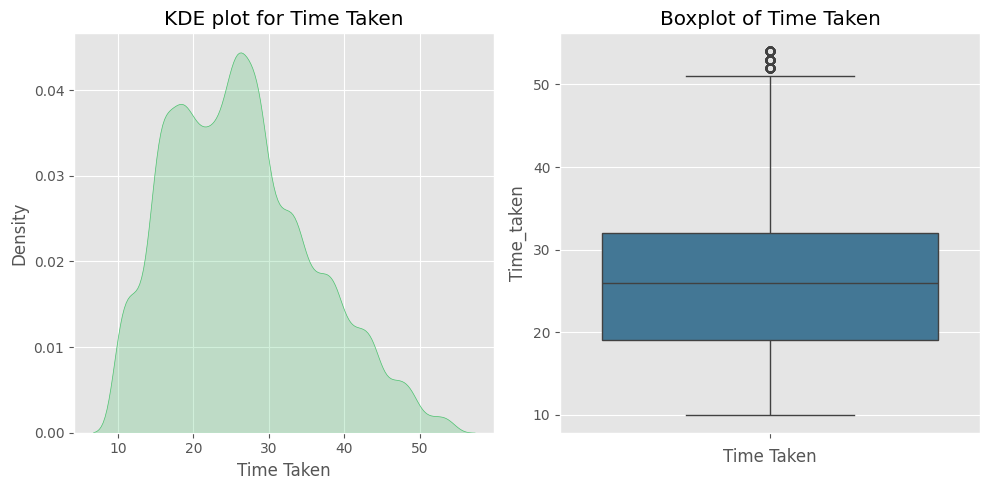

In [25]:
fig,axes = plt.subplots(1,2,figsize=(10,5))
numeric_df = df2.select_dtypes(exclude="object")

sns.kdeplot(numeric_df["Time_taken"],ax = axes[0],fill = True,color=sns.color_palette("viridis")[4])

axes[0].set_title("KDE plot for Time Taken")
axes[0].set_xlabel("Time Taken")
axes[0].set_ylabel("Density")

sns.boxplot(numeric_df["Time_taken"],ax = axes[1],palette="mako")

axes[1].set_title("Boxplot of Time Taken")
axes[1].set_xlabel("Time Taken")

plt.tight_layout()
plt.show()

Time taken slightly follows right skewed distribution as we can see there are few outliers from the boxplot

Categorical column

In [26]:
cat_df = df2.select_dtypes(include="object").iloc[:,2:-1]

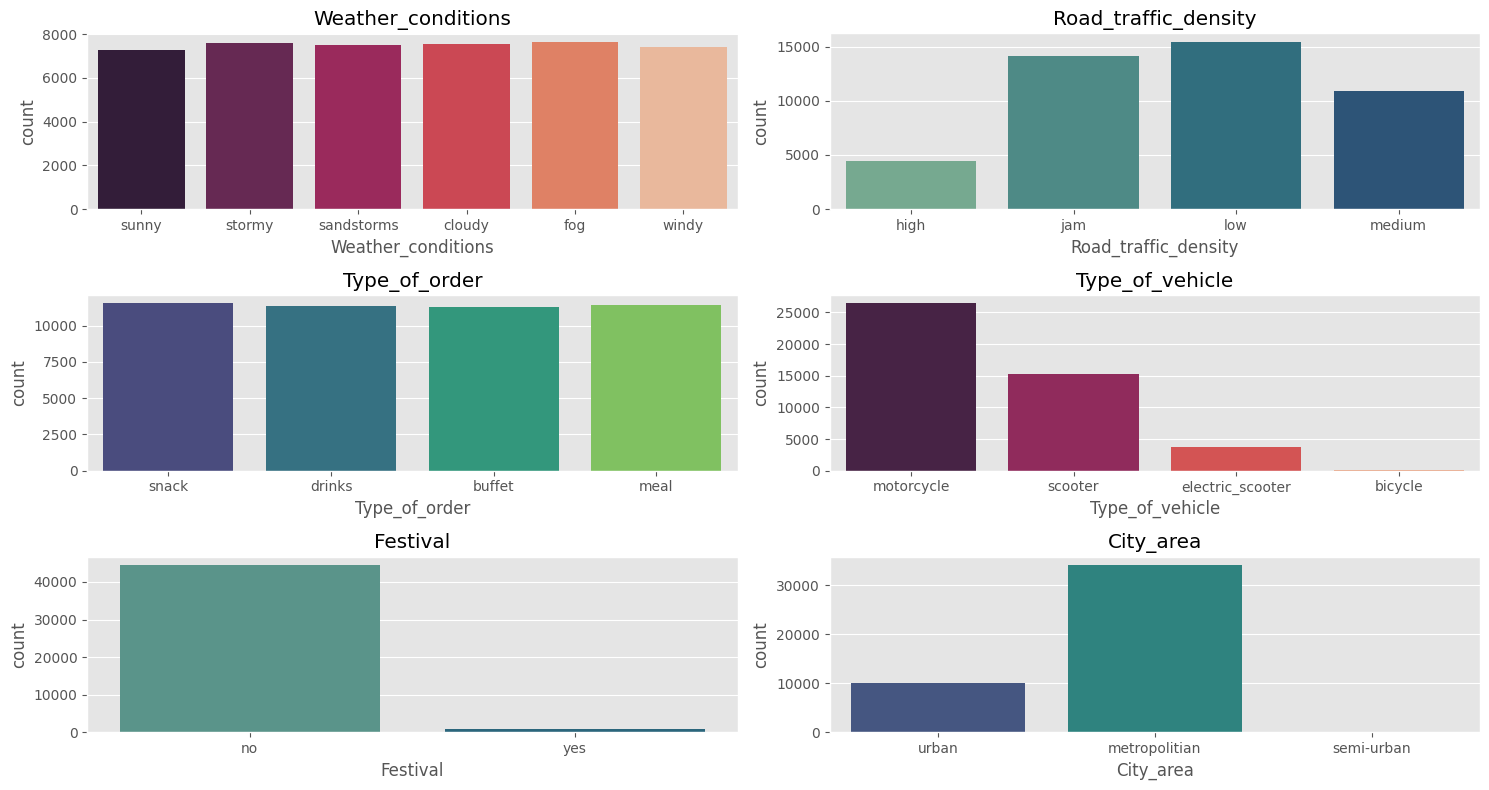

In [27]:
cat_df = df2.select_dtypes(include="object").iloc[:,2:-1]
palettes = ["rocket","crest","viridis"] * (len(cat_df.columns)//3)

fig,axes = plt.subplots(3,2,figsize=(15,8))
axes = axes.flatten()

for ax,column,palette in zip(axes,cat_df.columns,palettes):
    sns.countplot(x = cat_df[column],ax = ax,palette = palette)
    ax.set_title(f"{column}")

plt.tight_layout()  
plt.show()

* Weather conditions follows a uniform distribution

* Deliveries are predominantly made via motorcycle

* Road traffic density typically low,medium or jammed

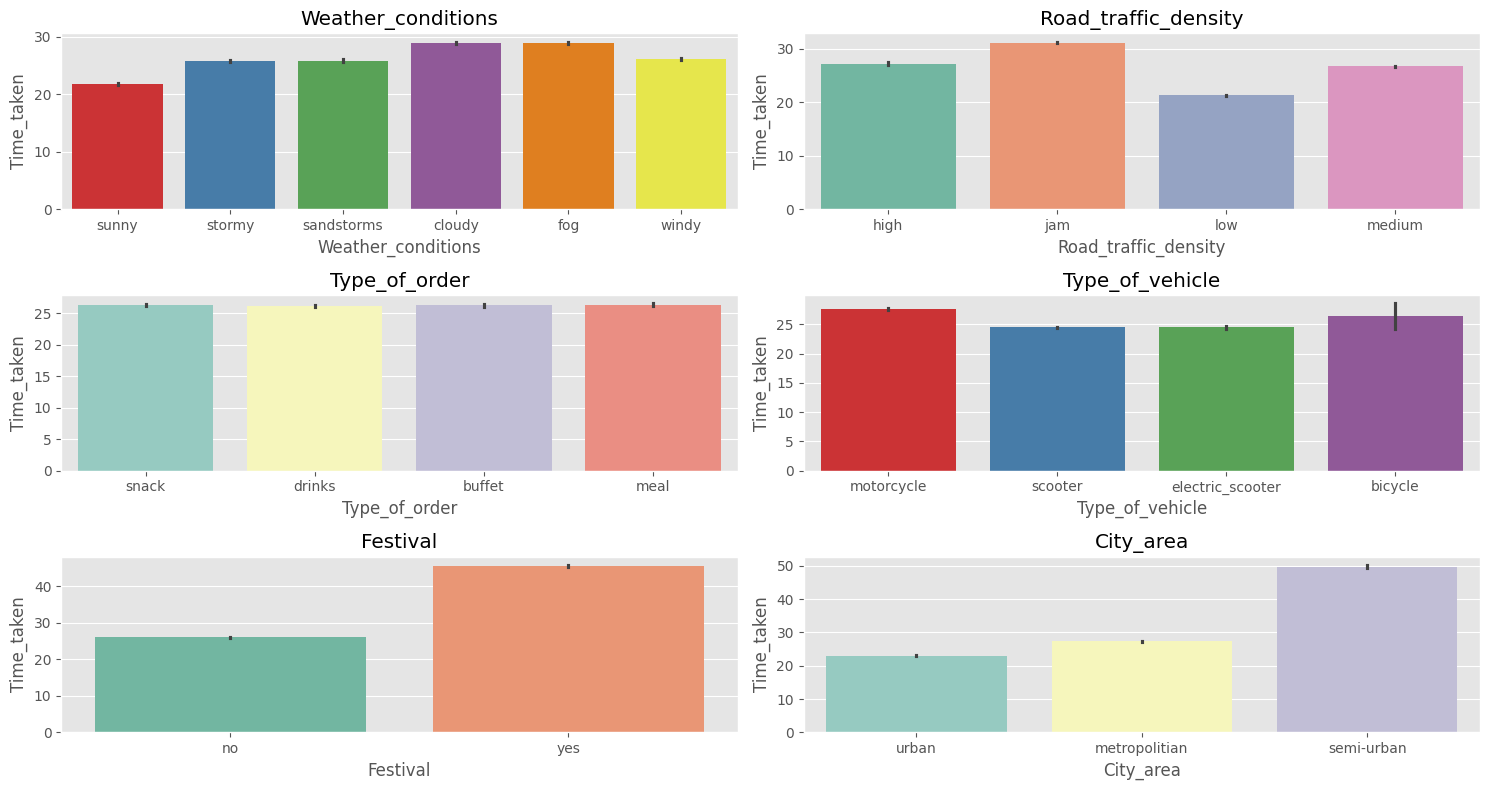

In [28]:
palettes = ["Set1","Set2","Set3"] * (len(cat_df.columns)//3)

fig,axes = plt.subplots(3,2,figsize=(15,8))
axes = axes.flatten()

for ax,column,palette in zip(axes,cat_df.columns,palettes):
    sns.barplot(x = cat_df[column],y = numeric_df["Time_taken"],ax = ax,palette = palette)
    ax.set_title(f"{column}")

plt.tight_layout()  
plt.show()

* Less Time Taken :- Low Traffic or Sunny day or Electric Scooter or No Festival or Urban Area

* More Time Taken :- Jammed Traffic or Fog day or Bicycle or Festival or Semi-urban Area

Numeric Column

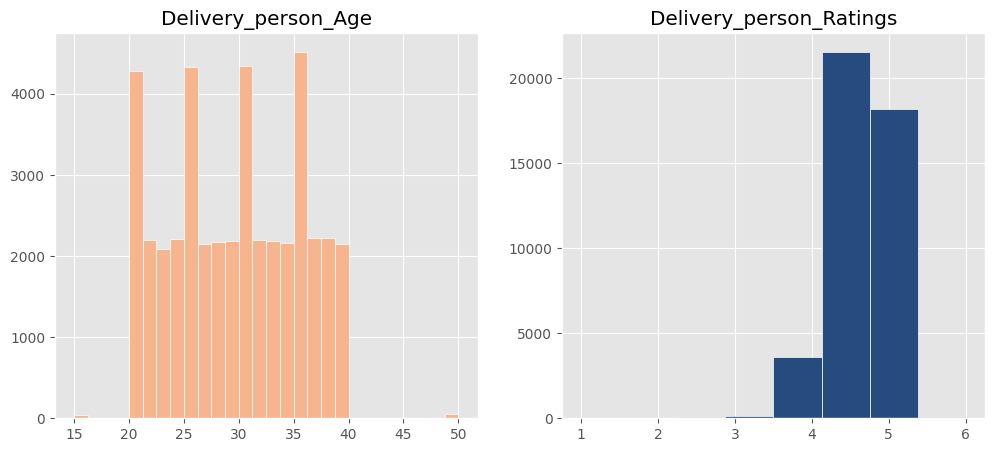

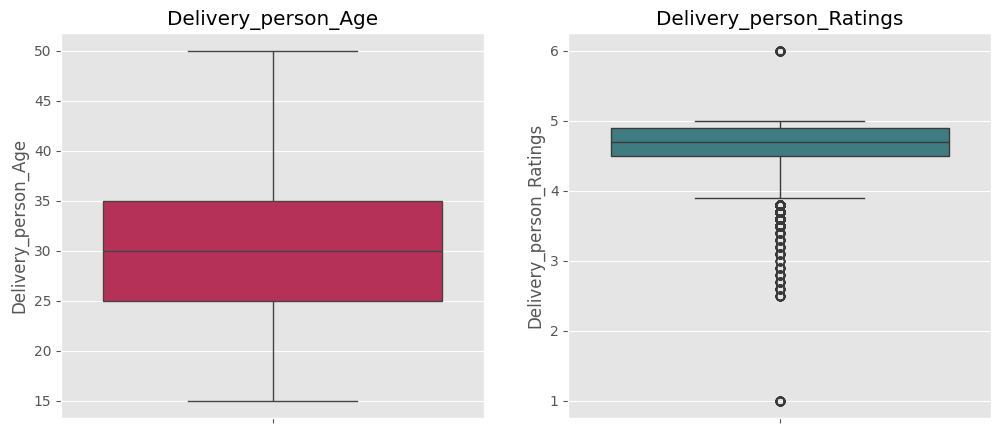

In [29]:
import math

num_cols = ["Delivery_person_Age","Delivery_person_Ratings"]

palettes = ["rocket","crest"]

fig,axes = plt.subplots(1,2,figsize=(12,5))
axes = axes.flatten()

for ax,palette,column in zip(axes,palettes,num_cols):
    n_bins = int(math.sqrt(numeric_df[column].max())) * 4
    ax.hist(numeric_df[column],color = sns.color_palette(palette)[5],edgecolor="white",bins=n_bins)
    ax.set_title(f"{column}")



fig_1,axes_1 = plt.subplots(1,2,figsize=(12,5))

for ax,palette,column in zip(axes_1,palettes,num_cols):
    sns.boxplot(numeric_df[column],ax = ax,palette = palette)
    ax.set_title(f"{column}")

plt.show()

* Delivery person age are in a range of 20 to 40

* Quite a huge frequency between 4 to 5 (delivery person ratings) need to check for rating 6

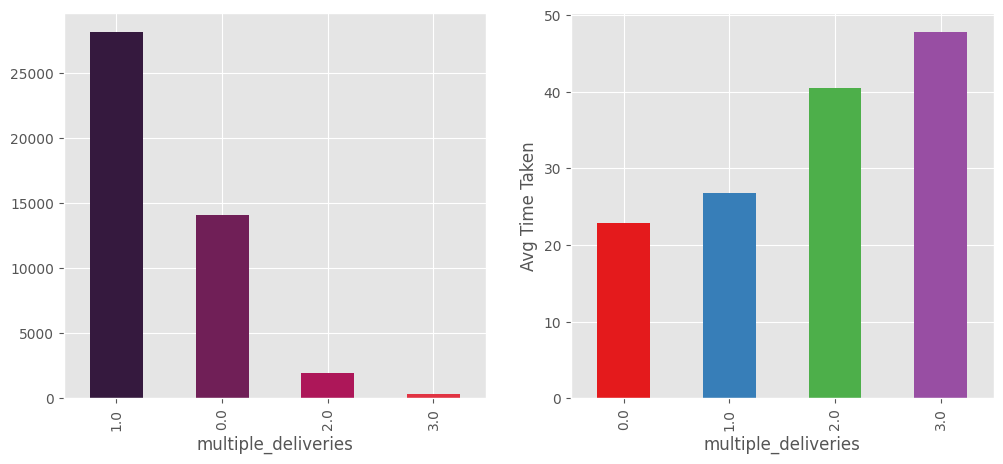

In [30]:
plt.figure(figsize=(12,5))


plt.subplot(1,2,1)

numeric_df["multiple_deliveries"].value_counts().plot(kind="bar",color=sns.color_palette("rocket"))


plt.subplot(1,2,2)

numeric_df.groupby("multiple_deliveries")["Time_taken"].mean().plot(kind="bar",color=sns.color_palette("Set1"))
plt.ylabel("Avg Time Taken")

plt.show()

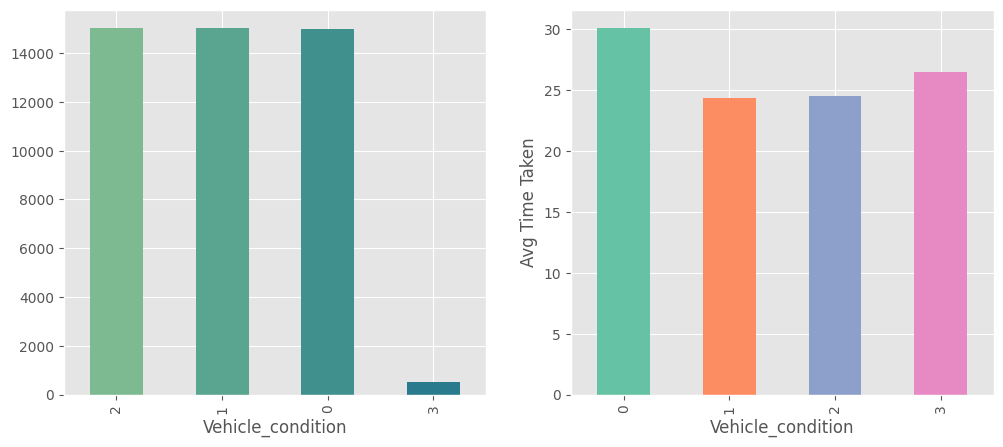

In [31]:
plt.figure(figsize=(12,5))


plt.subplot(1,2,1)

numeric_df["Vehicle_condition"].value_counts().plot(kind="bar",color=sns.color_palette("crest"))


plt.subplot(1,2,2)

numeric_df.groupby("Vehicle_condition")["Time_taken"].mean().plot(kind="bar",color=sns.color_palette("Set2"))
plt.ylabel("Avg Time Taken")

plt.show()

Counting orders per city and restaurant location

In [32]:
df2[["City","Restaurant_latitude","Restaurant_longitude"]].value_counts().to_frame()[:10]

count
City   Restaurant_latitude Restaurant_longitude       
vad    0.000000            0.000000               1590
ranchi 0.000000            0.000000                665
deh    0.000000            0.000000                245
agr    0.000000            0.000000                213
bhp    0.000000            0.000000                213
jap    26.911378           75.789034               182
       26.914142           75.805704               180
       26.892312           75.806896               176
       26.902908           75.792934               176
       26.902940           75.793007               176

checking valid coordinates

In [33]:
sum(df2["Restaurant_latitude"]==0.0)   # 3640
sum(df2["Restaurant_longitude"]==0.0)  # 3640

3640

Remove invalid coordinates

In [39]:
#check the coordinates

print(len(df2[(df2["Restaurant_latitude"]>=8) & (df2["Restaurant_latitude"]<=37)]))
print(len(df2[(df2["Restaurant_longitude"]>=68) & (df2["Restaurant_longitude"]<=97)]))

41522
41791


In [41]:
df3 = df2[-((df2["Restaurant_latitude"]==0.0) & (df2["Restaurant_longitude"]==0.0)) ]

In [42]:
df3.shape

(41953, 19)

In [45]:
restaurant_df = df3.groupby(["City","Restaurant_latitude","Restaurant_longitude"]).size().reset_index(name = "num_orders")

In [46]:
# max orders with each city and the restaurant coordinates 

top_restaurant = restaurant_df.loc[restaurant_df.groupby("City")["num_orders"].idxmax()]
top_restaurant.sort_values(by="num_orders",ascending=False)[:10]

,City,Restaurant_latitude,Restaurant_longitude,num_orders
368,jap,26.911378,75.789034,182
694,vad,22.308096,73.167753,172
293,hyd,17.430448,78.418213,170
576,mys,12.323978,76.627961,170
116,bang,12.979166,77.640709,170
642,ranchi,23.371292,85.327872,169
176,chen,13.058616,80.264151,168
323,indo,22.725748,75.898497,168
212,coimb,11.025083,77.015393,168
614,pune,18.569156,73.774723,167


In [47]:
print(f' year {df3["Order_Date"].dt.year.nunique()}')
print(f' month {df3["Order_Date"].dt.month.nunique()}')
print(f' days {df3["Order_Date"].dt.day.nunique()}')

 year 1
 month 3
 days 30


In [49]:
df3["month"] = df3["Order_Date"].dt.month
df3["day"] = df3["Order_Date"].dt.day

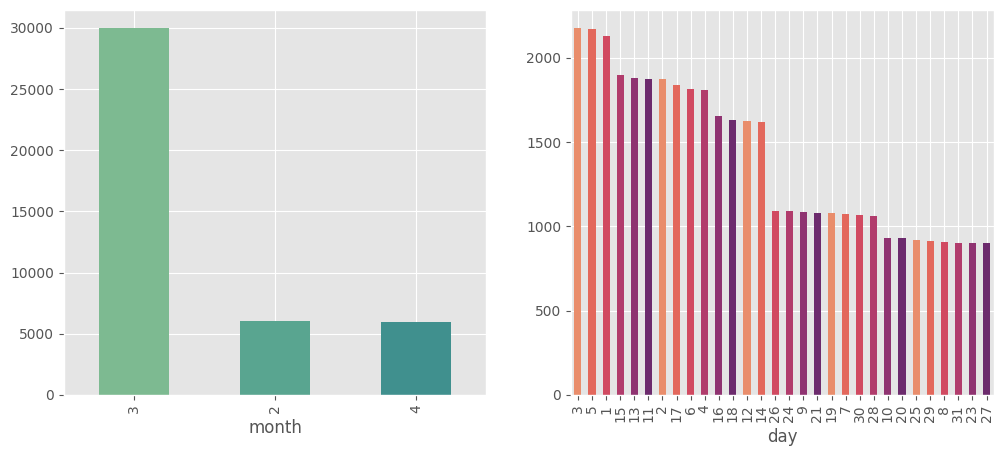

In [50]:
fig,axes = plt.subplots(1,2,figsize=(12,5))

df3["month"].value_counts().plot(kind="bar",color=sns.color_palette("crest"),ax = axes[0])
df3["day"].value_counts().plot(kind="bar",color=sns.color_palette("flare"),ax = axes[1])

plt.show()

* Majority of orders came form 3rd month of year

* Also we can see that 3rd day of every month represent high number of orders

# ****Missing Values Treatment****

In [51]:
# lets check again for missing values 

df3.isnull().sum().sort_values(ascending=False)

Delivery_person_Ratings        1763
Delivery_person_Age            1719
Time_Orderd                    1600
City_area                      1114
multiple_deliveries             905
Weather_conditions              569
Road_traffic_density            555
Festival                        215
Order_Date                        0
Time_Order_picked                 0
Type_of_order                     0
Type_of_vehicle                   0
City                              0
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Vehicle_condition                 0
Time_taken                        0
month                             0
day                               0
dtype: int64

Imputing Delivery Person Age

By seeing the distribution it looks like it is a uniform distribution

In [52]:
null_count = df3["Delivery_person_Age"].isnull().sum()
min_value = df3["Delivery_person_Age"].min()
max_value = df3["Delivery_person_Age"].max()
uniform_age_ary = np.random.randint(min_value,max_value,null_count)
uniform_age_ary

array([33, 20, 15, ..., 46, 18, 16])

In [53]:
# for checking 

age_b_df = df3.copy()

In [54]:
null_indices = df3[df3["Delivery_person_Age"].isnull()].index

In [55]:
df3.loc[null_indices,"Delivery_person_Age"] = uniform_age_ary

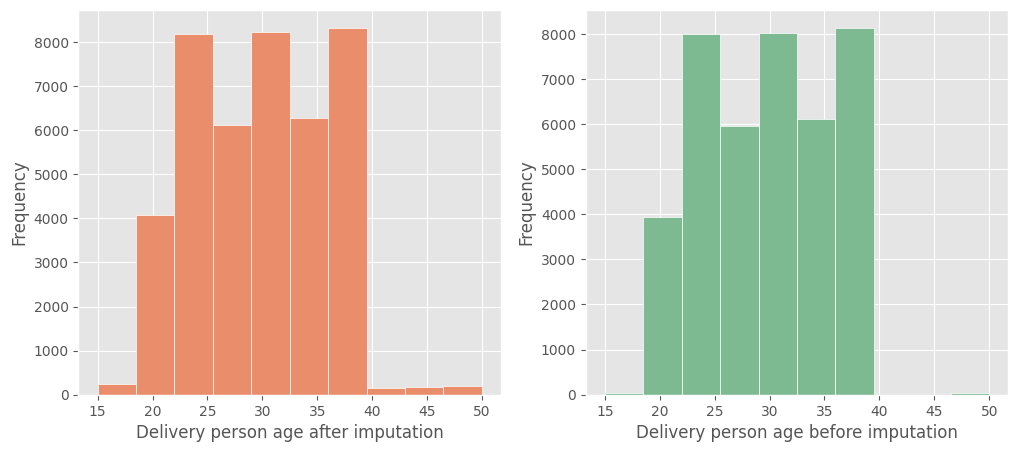

In [56]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

df3["Delivery_person_Age"].plot(kind="hist",color=sns.color_palette("flare"),edgecolor="white")
plt.xlabel("Delivery person age after imputation")

plt.subplot(1,2,2)

age_b_df["Delivery_person_Age"].plot(kind="hist",color=sns.color_palette("crest"),edgecolor="white")
plt.xlabel("Delivery person age before imputation")

plt.show()

Imputing Delivery person ratings

In [57]:
df3["Delivery_person_Ratings"].describe()

count    40190.000000
mean         4.632386
std          0.335541
min          1.000000
25%          4.500000
50%          4.700000
75%          4.900000
max          6.000000
Name: Delivery_person_Ratings, dtype: float64

In [58]:
df3[df3["Delivery_person_Ratings"]>5].sample(4)

,Delivery_person_Age,Delivery_person_Ratings,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Type_of_order,Type_of_vehicle,multiple_deliveries,...,City_area,City,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,Time_taken,month,day
38007,50.0,6.0,2022-02-14,NaN,18:05:00,NaN,NaN,snack,electric_scooter,1.0,...,metropolitian,deh,30.366322,78.070453,30.436322,78.140453,3,25,2,14
24237,50.0,6.0,2022-03-15,NaN,10:10:00,NaN,NaN,meal,motorcycle,0.0,...,metropolitian,sur,-21.170096,-72.789122,21.180096,72.799122,3,17,3,15
27399,50.0,6.0,2022-03-24,NaN,23:20:00,NaN,NaN,meal,electric_scooter,1.0,...,metropolitian,mum,19.103249,72.846749,19.133249,72.876749,3,18,3,24
9499,50.0,6.0,2022-03-12,NaN,18:25:00,NaN,NaN,drinks,scooter,1.0,...,urban,bang,12.933298,77.614293,13.003298,77.684293,3,17,3,12


In [59]:
print((df3["Delivery_person_Ratings"]>5).sum())

46


I assume that ratings feature have rating between 1 to 5

We can considered as a missing values and we can impute with median value based on distribution

In [60]:
# for checking 

rating_b_df = df3.copy()

In [61]:
df3["Delivery_person_Ratings"].fillna(df3["Delivery_person_Ratings"].median(),inplace=True)

In [62]:
rating_indices = df3[df3["Delivery_person_Ratings"]==6].index
df3.loc[rating_indices,"Delivery_person_Ratings"] = df3["Delivery_person_Ratings"].median()

In [63]:
print("Before")
print(rating_b_df["Delivery_person_Ratings"].describe())
print("------------------------------")
print("After")
print(df3["Delivery_person_Ratings"].describe())

Before
count    40190.000000
mean         4.632386
std          0.335541
min          1.000000
25%          4.500000
50%          4.700000
75%          4.900000
max          6.000000
Name: Delivery_person_Ratings, dtype: float64
------------------------------
After
count    41953.000000
mean         4.633802
std          0.325577
min          1.000000
25%          4.500000
50%          4.700000
75%          4.800000
max          5.000000
Name: Delivery_person_Ratings, dtype: float64


Imputing categorical columns

In [64]:
cols = ["multiple_deliveries","Road_traffic_density","City_area","Festival"]

for col in cols:
    df3[col].fillna(df3[col].mode()[0],inplace=True) 

Imputing Weather Conditions

In [65]:
w_types = df3["Weather_conditions"].unique()[:-1]

In [66]:
null_count_for_w = df3["Weather_conditions"].isnull().sum()

In [67]:
w_missing_list = []

for w_type in w_types:
    l = []
    for i in range(null_count_for_w//len(w_types)):
        l.append(w_type)
    w_missing_list.extend(l)

In [68]:
temp_df = df3[-(df3["Weather_conditions"].isnull())]

w_missing_list.extend(temp_df["Weather_conditions"].sample(null_count_for_w-len(w_missing_list)).values)

In [69]:
w_indices = df3[df3["Weather_conditions"].isnull()].index
df3.loc[w_indices,"Weather_conditions"] = w_missing_list

In [70]:
df3["Weather_conditions"].value_counts()

Weather_conditions
fog           7107
stormy        7069
cloudy        7026
sandstorms    7002
windy         6926
sunny         6823
Name: count, dtype: int64

Save preprocessed dataset

In [71]:

df3.to_csv("preprocessed_data.csv", index=False)